In [6]:
import numpy as np
import matplotlib.pyplot as plt


# DONNÉES (27 ÉTUDIANTS)
# Chaque ligne représente un étudiant :
#
# F1 = heures d'étude
# F2 = participation
# F3 = exercices rendus
# F4 = score de contrôle
# F5 = absences
# F6 = projets réalisés

In [7]:

X = np.array([  #la matrice des caractéristiques (features)

    [2,5,8,20,0,6],
    [4,6,6,40,2,5],
    [6,7,5,60,3,4],
    [8,7,4,80,4,3],
    [10,8,3,90,5,2],
    [3,4,9,30,0,7],
    [7,6,5,70,3,4],

    [5,5,6,50,2,5],
    [9,8,4,85,4,3],
    [1,3,9,15,1,8],
    [6,6,5,65,3,4],
    [7,7,4,75,3,3],
    [8,8,3,88,4,2],
    [2,4,8,25,1,6],
    [3,5,7,35,2,6],

    [4,7,6,45,2,5],
    [5,6,6,55,3,4],
    [6,8,5,68,3,3],
    [7,5,5,72,4,3],
    [9,7,4,82,4,2],

    [10,9,3,95,5,1],
    [2,3,9,10,1,9],
    [3,4,8,28,2,7],
    [6,5,6,60,3,4],
    [7,6,5,70,3,3],
    [8,7,4,78,4,2],
    [9,8,3,88,5,2]

])


In [8]:

# NOTES FINALES (TARGET)

notes = np.array([10,13,15,17,18.5,11,16,
                  12,17,9,14,15,18,10,11,
                  13,14,15,16,17,
                  19,8,9,14,15,16,17]) #les notes finales (target)


Classes session normale (1=réussi, 0=échec)
[0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1]

Données rattrapage :
Nombre d'étudiants = 7
Labels = [1 1 0 1 1 0 0]
Iteration 0 | Loss = 0.6931
Iteration 200 | Loss = 0.0735
Iteration 400 | Loss = 0.0402
Iteration 600 | Loss = 0.0275
Iteration 800 | Loss = 0.0209

PROBABILITÉS RATTRAPAGE
[9.99892280e-01 9.85330979e-01 4.15054414e-03 9.72407382e-01
 9.80160114e-01 9.61236648e-05 4.95053272e-02]

CLASSES PRÉDITES
[1 1 0 1 1 0 0]


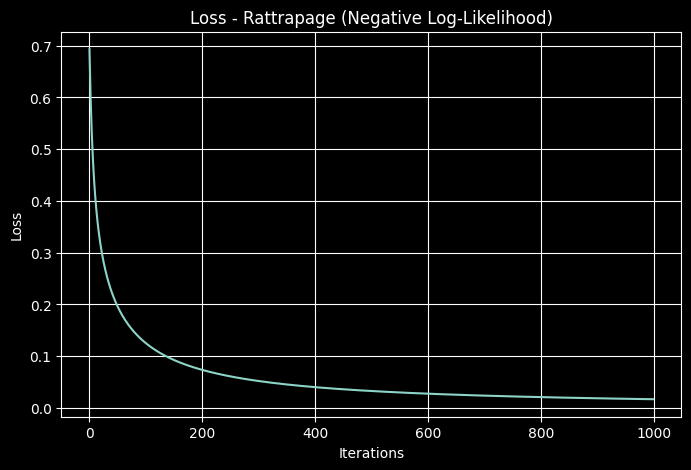

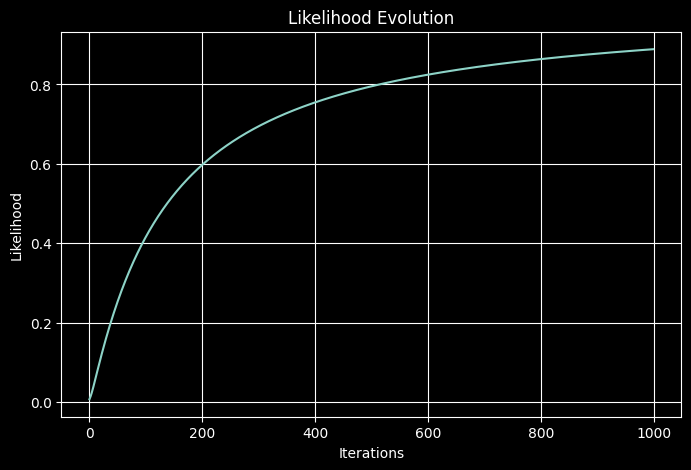

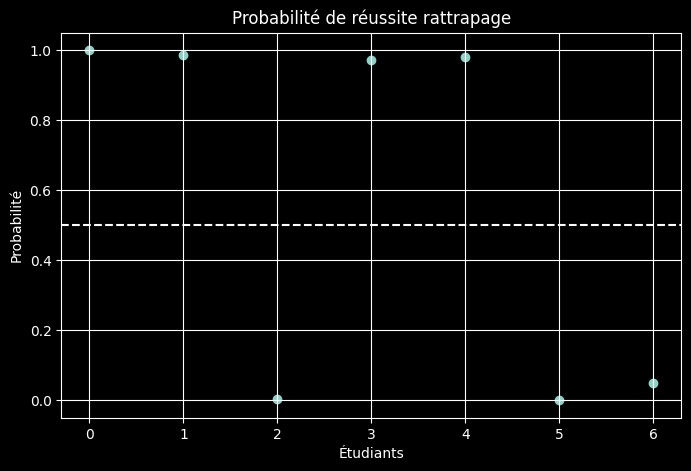

In [9]:
# 1) SESSION NORMALE SIMULATION
# règle :
# - si note >= 12 → réussite normale
# - sinon → échec → rattrapage
#

y_normal = (notes >= 12).astype(int)    # 1 = réussite normale, 0 = échec normal (rattrapage)

print("Classes session normale (1=réussi, 0=échec)")
print(y_normal)


# 2) FILTRAGE POUR RATTRAPAGE
# on garde uniquement les étudiants en échec normal
#

X = X[y_normal == 0]
notes = notes[y_normal == 0] #  les notes des étudiants en échec normal


# 3) CIBLE RATTRAPAGE
#
# règle rattrapage :
# - note >= 10 → réussite
# - sinon → échec
#

y = (notes >= 10).astype(int)

print("\nDonnées rattrapage :")
print("Nombre d'étudiants =", len(X))
print("Labels =", y)


# 4) NORMALISATION DES DONNÉES
# formule :
#   x_norm = (x - μ) / σ
#
# permet d'éviter domination d'une variable
#

X_mean = np.mean(X, axis=0) # μ
X_std = np.std(X, axis=0)   # σ

X = (X - X_mean) / X_std


# 5) FONCTION SIGMOID

# transforme une valeur en probabilité [0,1]
#
#           1
# σ(z) = ---------
#        1 + e^-z
#

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# 6) INITIALISATION

m, n = X.shape

W = np.zeros(n)   # poids
b = 0             # biais

lr = 0.1          # learning rate
epochs = 1000

loss_history = []
likelihood_history = []


# 7) ENTRAÎNEMENT (GRADIENT DESCENT)
# objectif :
# maximiser la log-vraisemblance
# équivalent à minimiser -log likelihood
#

for i in range(epochs):

    # prédiction linéaire
    z = np.dot(X, W) + b

    # activation sigmoïde
    y_pred = sigmoid(z)
    # LIKELIHOOD
    # L = Π (ŷ^y * (1-ŷ)^(1-y))
    #

    likelihood = np.prod(
        (y_pred ** y) *
        ((1 - y_pred) ** (1 - y))
    )

    likelihood_history.append(likelihood)

    # LOG-LIKELIHOOD

    log_likelihood = np.sum(
        y * np.log(y_pred + 1e-9)
        +
        (1 - y) * np.log(1 - y_pred + 1e-9)
    )

    # LOSS = - LOG-LIKELIHOOD

    loss = -np.mean(
        y * np.log(y_pred + 1e-9)
        +
        (1 - y) * np.log(1 - y_pred + 1e-9)
    )

    loss_history.append(loss)

    # GRADIENTS

    dw = np.dot(X.T, (y_pred - y)) / m
    db = np.mean(y_pred - y)

   # UPDATE PARAMÈTRES

    W = W - lr * dw
    b = b - lr * db

    if i % 200 == 0:
        print(f"Iteration {i} | Loss = {loss:.4f}")


# 8) PRÉDICTION

def predict(X_input):

    X_scaled = (X_input - X_mean) / X_std

    z = np.dot(X_scaled, W) + b
    proba = sigmoid(z)

    prediction = (proba >= 0.5).astype(int)

    return prediction, proba


classes_predites, probas = predict(X * X_std + X_mean)


print("\n==============================")
print("PROBABILITÉS RATTRAPAGE")
print(probas)

print("\nCLASSES PRÉDITES")
print(classes_predites)


# 9) VISUALISATION

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss - Rattrapage (Negative Log-Likelihood)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(likelihood_history)
plt.title("Likelihood Evolution")
plt.xlabel("Iterations")
plt.ylabel("Likelihood")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(range(len(probas)), probas)
plt.axhline(y=0.5, linestyle='--')
plt.title("Probabilité de réussite rattrapage")
plt.xlabel("Étudiants")
plt.ylabel("Probabilité")
plt.grid(True)
plt.show()

# 10) RÉSUMÉ MATHÉMATIQUE
# X → étudiants en échec normal
# ↓
# z = XW + b
# ↓
# ŷ = sigmoid(z)
# ↓
# likelihood = produit des probabilités
# ↓
# log-likelihood
# ↓
# loss = -log likelihood
# ↓
# gradient descent
# ↓
# optimisation de W et b
#
# ============================================================